In [124]:
from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd


In [125]:
data = pd.read_csv('Data/Summary_aboveChance.csv', index_col=[0,1,2,3], header=[0,1])
data = data['Correlation'].reset_index()
data.columns = ['ComparisonType', 'Target', 'System', 'Group', 'Accuracy', 'Sig']
bar_sig = data
# change System: Lang -> Language (LH), Lang_RH -> Language (Right)
system_name_map = {
    'Lang': 'Language (LH)',
    'Lang_RH': 'Language (right)',
    'MD': 'MD'
}
bar_sig['System'] = bar_sig['System'].map(system_name_map)

In [126]:
test_results = []
for target in ['conditions', 'tasks']:
    test_result = pd.read_csv(f'Data/Tests_{target}_decoding.csv', index_col=0)
    test_result['Target'] = target
    test_results.append(test_result)
test_results = pd.concat(test_results, ignore_index=True)
test_results['ComparisonType'] = test_results['contrast'].apply(lambda x: x.split(':')[0])
test_results['Group'] = test_results['contrast'].apply(lambda x: x.split(':')[-1])
comparison_type_map = {
    'Diff': 'cross',
    'Same': 'same'
}
test_results['ComparisonType'] = test_results['ComparisonType'].map(comparison_type_map)
test_results['Significance'] = test_results['p.value'].apply(
    lambda p: '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'n.s.'
)

In [127]:
test_results

,contrast,estimate,SE,df,z.ratio,p.value,Target,ComparisonType,Group,Significance
0,Diff:Language:V1 - Diff:MD:V1,0.428423,0.057213,inf,7.488161,2.095352e-13,conditions,cross,V1,***
1,Same:Language:V1 - Same:MD:V1,0.523158,0.057555,inf,9.089667,2.980275e-19,conditions,same,V1,***
2,Diff:Language:V2 - Diff:MD:V2,0.476811,0.057766,inf,8.254218,4.587019e-16,conditions,cross,V2,***
3,Same:Language:V2 - Same:MD:V2,0.533771,0.058454,inf,9.131415,2.028291e-19,conditions,same,V2,***
4,Diff:Language:V3 - Diff:MD:V3,0.495265,0.057130,inf,8.669100,1.306644e-17,conditions,cross,V3,***
5,Same:Language:V3 - Same:MD:V3,0.553605,0.057398,inf,9.644971,1.548771e-21,conditions,same,V3,***
6,Diff:MD:N - Diff:Language:N,0.295503,0.045701,inf,6.466067,2.011732e-10,tasks,cross,N,***
7,Same:MD:N - Same:Language:N,0.208783,0.045395,inf,4.599266,8.479658e-06,tasks,same,N,***
8,Diff:MD:S - Diff:Language:S,0.287284,0.045705,inf,6.285660,6.529259e-10,tasks,cross,S,***
9,Same:MD:S - Same:Language:S,0.094765,0.045147,inf,2.099018,7.163064e-02,tasks,same,S,n.s.


In [128]:
# colors_tasks = ['#606060', '#0000ff', '#00aaff']
# colors_conditions = ["#ff0000", "#30d5c8"]

/var/folders/k0/md38zs8x1395ywbtngppz3k00000gp/T/ipykernel_64605/1553981488.py:108: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['V1→V1', 'V2→V2', 'V3→V3'])
/var/folders/k0/md38zs8x1395ywbtngppz3k00000gp/T/ipykernel_64605/1553981488.py:112: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['S→S', 'N→N'])
/var/folders/k0/md38zs8x1395ywbtngppz3k00000gp/T/ipykernel_64605/1553981488.py:110: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['V2/V3→V1', 'V1/V3→V2', 'V1/V2→V3'])
/var/folders/k0/md38zs8x1395ywbtngppz3k00000gp/T/ipykernel_64605/1553981488.py:114: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.s

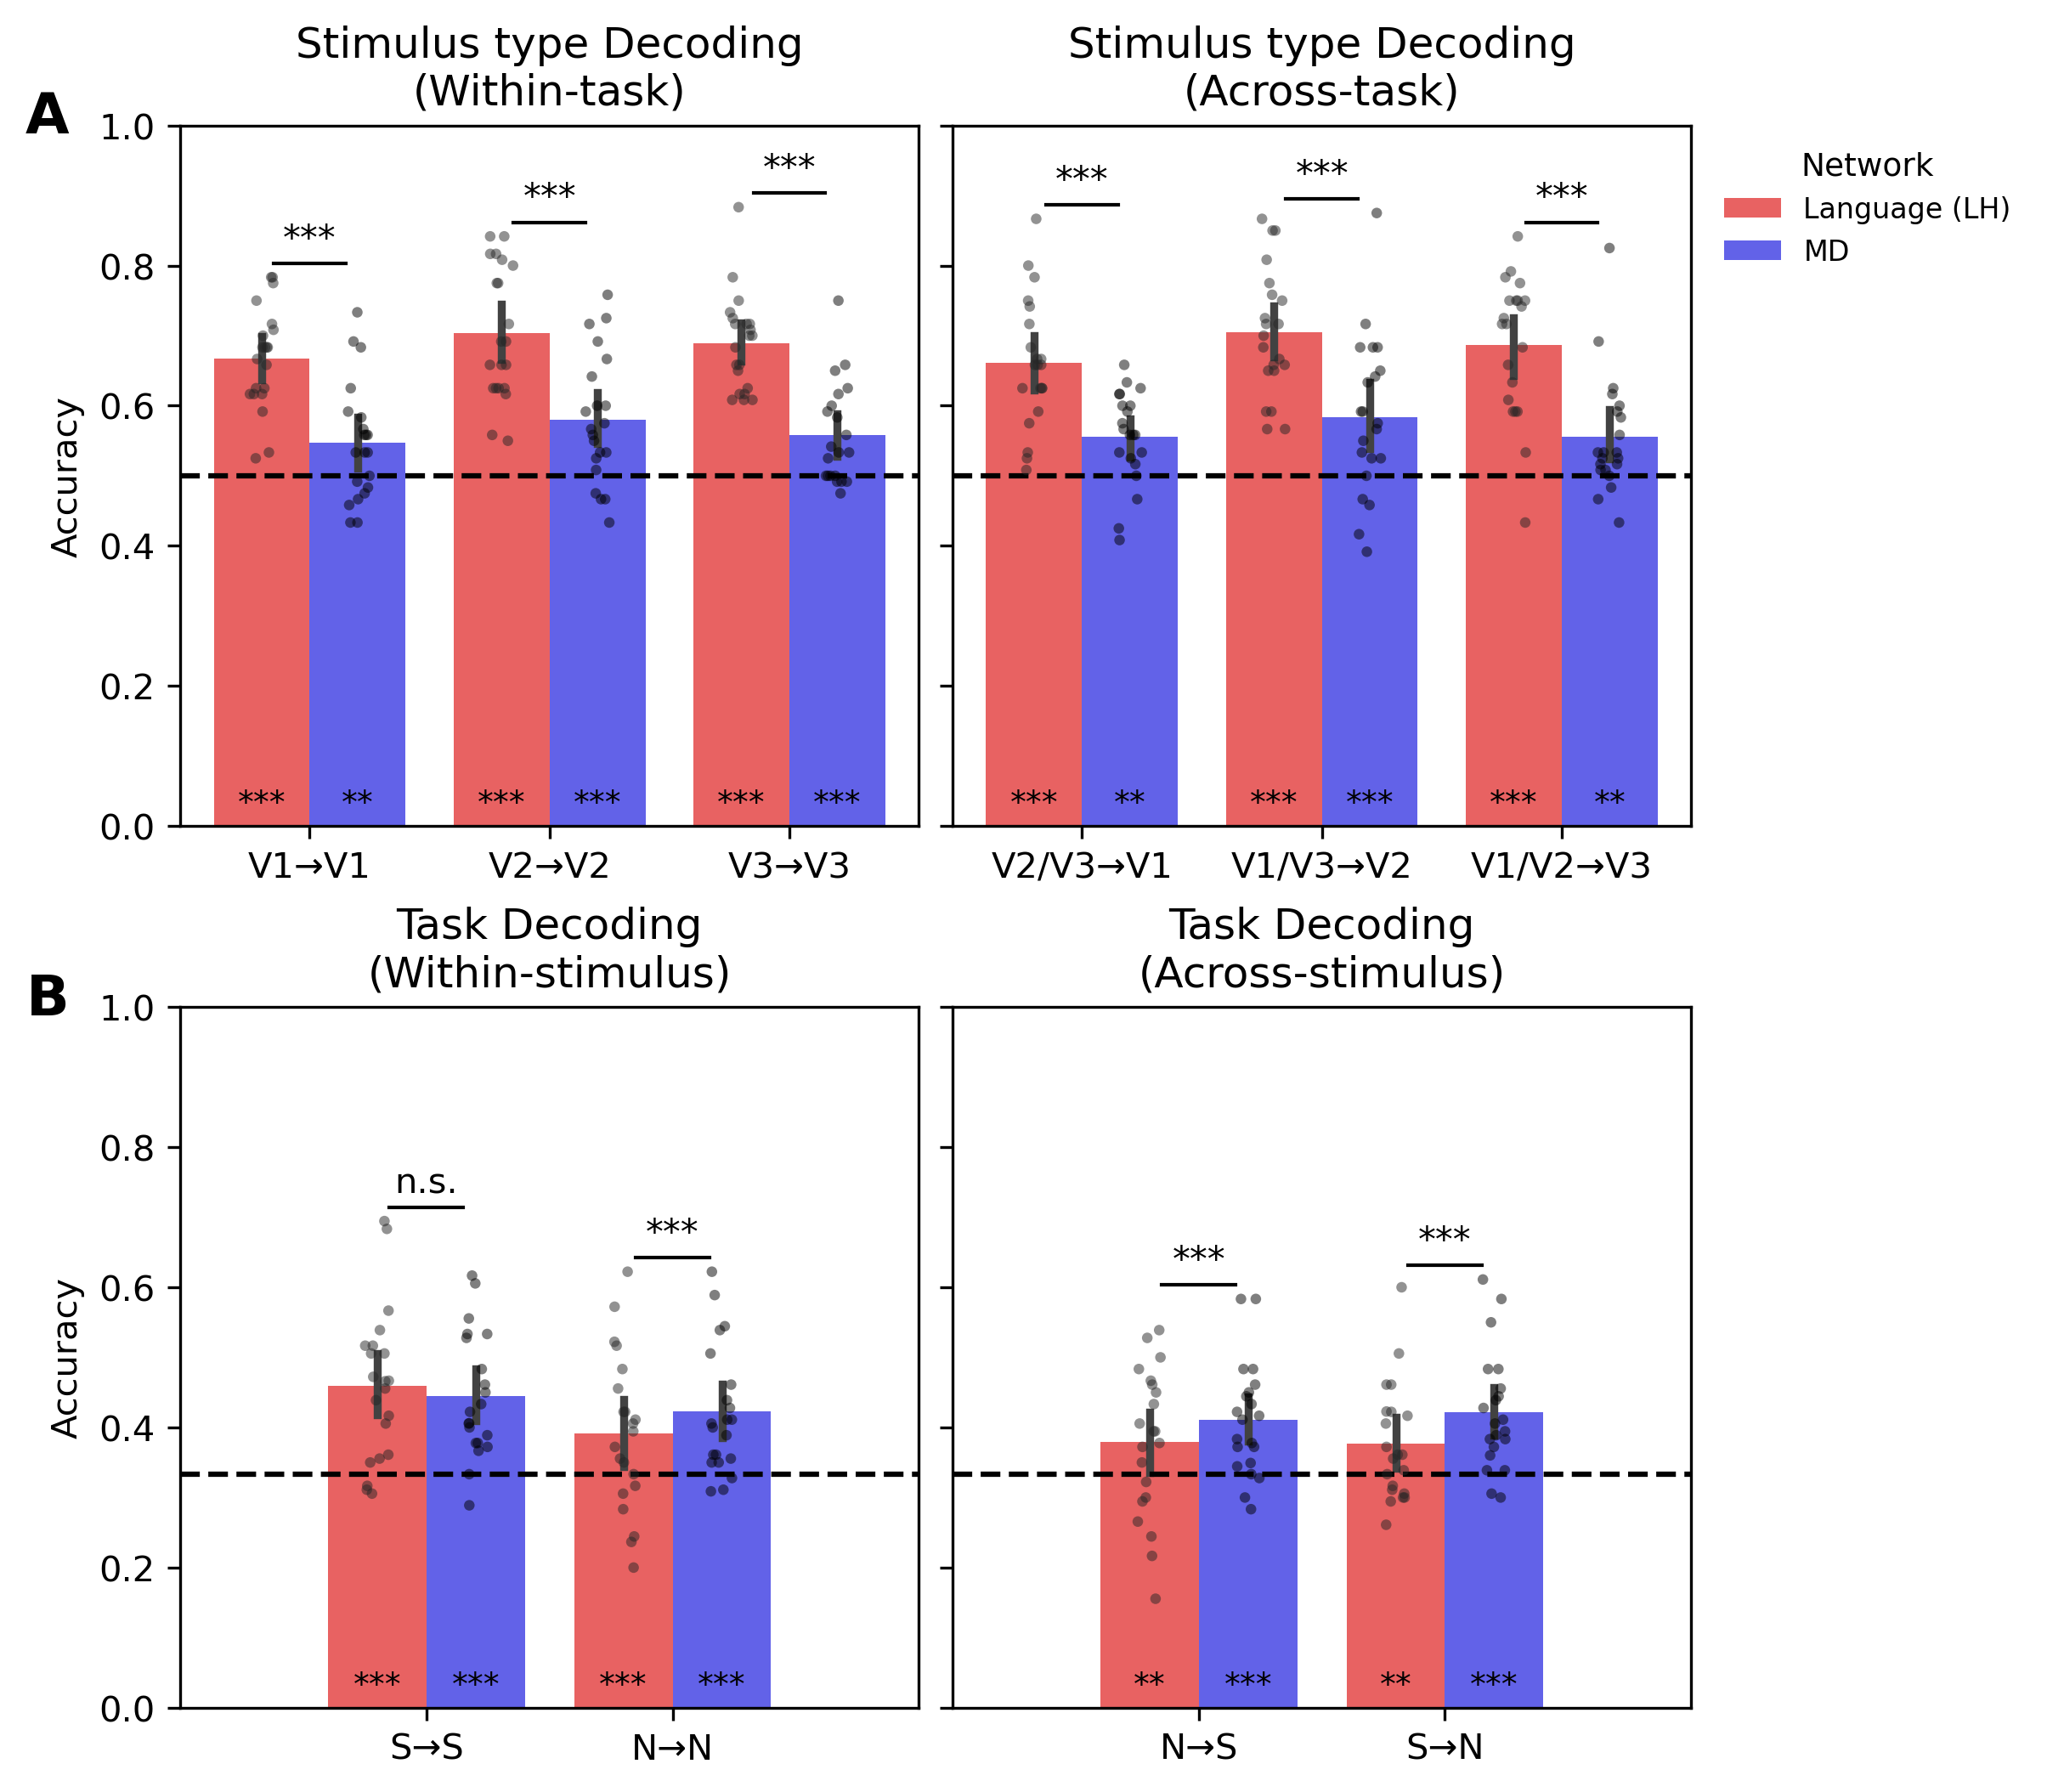

In [129]:
# Normalize across blocks per run
normalize = 'pattern'
fig, axs = plt.subplots(2, 2, figsize=(8, 7), dpi=300, constrained_layout=True,
                        sharey=True)
for i, train_type in enumerate(['same', 'cross']):
    for j, target in enumerate(['conditions', 'tasks']):
        ax = axs[j, i]
        data = []
        for network in ['Lang', 'MD']:
            pth = f'Data/mvpa_{network}_{target}_{train_type}_{normalize}.csv'
            df = pd.read_csv(pth)
            df = df.loc[df['Classifier'] == 'Correlation']
            df = df[['Subject', 'TestGroup', 'Accuracy']].groupby(['Subject', 'TestGroup']).mean().reset_index()
            df['network'] = 'Language (LH)' if network == 'Lang' else 'MD'
            data.append(df)
        data = pd.concat(data, ignore_index=True)

        sns.barplot(data=data, x='TestGroup', y='Accuracy', hue='network', 
                    order=['V1', 'V2', 'V3'] if target == 'conditions' else ['S', 'N'],
                    hue_order=['Language (LH)', 'MD'],
                    palette=['red', 'blue'], alpha=0.7,
                    ax=ax)
        sns.stripplot(data=data, x='TestGroup', y='Accuracy', hue='network',
                    legend=False, order=['V1', 'V2', 'V3'] if target == 'conditions' else ['S', 'N'],
                    hue_order=['Language (LH)', 'MD'],
                    palette="dark:black",
                    dodge=True, alpha=0.5, jitter=True, size=3,
                    ax=ax)
        
                # --- Add significance annotations ---
        pairs = (
            ['V1', 'V2', 'V3'] if target == 'conditions'
            else ['S', 'N']
        )

        for x_i, grp in enumerate(pairs):
            # print(target, train_type, grp)
            sig = test_results.loc[
                (test_results['Target'] == target) &
                (test_results['ComparisonType'] == train_type) &
                (test_results['Group'] == grp), 'Significance'
            ].values[0]
            # Get y-max for this group
            y_max = data.loc[data['TestGroup'] == grp, 'Accuracy'].max()
            # X positions for Language and MD bars in the cluster
            if target == 'conditions':
                x_center = x_i
            else:
                x_center = x_i

            # approximate bar width separation
            offset = 0.15
            x_lang = x_center - offset
            x_md = x_center + offset

            # line + annotation
            ax.plot([x_lang, x_md], [y_max + 0.02, y_max + 0.02], color='k', lw=1)
            ax.text(x_center, y_max + 0.03, sig, ha='center', va='bottom', fontsize=10)

        for x_i, grp in enumerate(pairs):
            d_grp = data[data['TestGroup'] == grp]
            y_lang = d_grp.loc[d_grp['network'] == 'Language (LH)', 'Accuracy'].mean()
            y_md   = d_grp.loc[d_grp['network'] == 'MD', 'Accuracy'].mean()

            sig_lang = bar_sig.loc[
                (bar_sig['Target'] == target) &
                (bar_sig['ComparisonType'] == train_type) &
                (bar_sig['Group'] == grp) &
                (bar_sig['System'] == 'Language (LH)'), 'Sig'
            ].values[0]
            sig_md   = bar_sig.loc[
                (bar_sig['Target'] == target) &
                (bar_sig['ComparisonType'] == train_type) &
                (bar_sig['Group'] == grp) &
                (bar_sig['System'] == 'MD'), 'Sig'
            ].values[0]

            offset = 0.2
            x_lang = x_i - offset
            x_md   = x_i + offset

            # --- per-patch (each bar) mark ---
            ax.text(x_lang, 0 + 0.01, sig_lang, ha='center', va='bottom', fontsize=9)
            ax.text(x_md,   0 + 0.01, sig_md, ha='center', va='bottom', fontsize=9)



        target_ = 'Task Decoding' if target == 'tasks' else 'Stimulus type Decoding'
        if target == 'conditions':
            train_type_ = 'Within-task' if train_type == 'same' else 'Across-task'
        else:
            train_type_ = 'Within-stimulus' if train_type == 'same' else 'Across-stimulus'
        ax.set_title(f'{target_}\n({train_type_})')
        ax.set_ylim(0, 1)
        ax.set_ylabel('Accuracy')
        ax.set_xlabel('')

        bychance = 0.5 if target == 'conditions' else 1./3
        ax.axhline(y=bychance, color='black', linestyle='--')

        if i == 1 and j == 0:
            ax.legend(title='Network', loc='upper left', fontsize=8, title_fontsize=9, frameon=False, bbox_to_anchor=(1.01, 1))
        else:
            ax.get_legend().remove()

        # change xticklabels
        if j == 0 and i == 0:
            ax.set_xticklabels(['V1→V1', 'V2→V2', 'V3→V3'])  
        elif j == 0 and i == 1:
            ax.set_xticklabels(['V2/V3→V1', 'V1/V3→V2', 'V1/V2→V3'])
        elif j == 1 and i == 0:
            ax.set_xticklabels(['S→S', 'N→N'])  
        else:
            ax.set_xticklabels(['N→S', 'S→N'])

        if j == 1:
            ax.set_xlim(-1, 2)

        # add A and B for rows
        if i == 0 and j == 0:
            ax.text(-0.15, 1.05, 'A', transform=ax.transAxes, fontsize=16, fontweight='bold', va='top', ha='right')
        elif i == 0 and j == 1:
            ax.text(-0.15, 1.05, 'B', transform=ax.transAxes, fontsize=16, fontweight='bold', va='top', ha='right')
fig.supylabel('')
fig.supxlabel('')
fig.savefig(f'Figures_20251013/mvpa_{normalize}.png', dpi=300, transparent=True)